# Multi-atlas boundary comparison and ROC-boundary relationship analysis

In [1]:
library(ggplot2)
library(Seurat)
library(dplyr)
library(readr)
library(tidyr)
library(RANN)
library(matrixStats)

output_dir <- "results/boundary_analysis"
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

Warning message:
“package ‘Seurat’ was built under R version 4.2.2”
Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘RANN’ was built under R version 4.2.1”

Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count




In [2]:
#The processed segment × genes files and segment × cells files can be downloaded at https://db.genomics.cn/stomics/mccsta/
gene_roc_obj <- readRDS(file.path(base_dir, "Segment_genes_ROC_marmoset.rds"))
celltype_roc_obj <- readRDS("data/Segment_celltypes_ROC_marmoset.rds")

In [3]:
# The atlas mappings can be downloaded at https://db.genomics.cn/stomics/mccsta/
atlas_mappings <- read_csv("data/atlas_mappings.csv", show_col_types = FALSE)

In [4]:
# Border detection function
detect_region_border <- function(obj_meta, region_col, X='x', Y='y', knn=3) {
    tmp <- obj_meta[, c(X, Y, region_col)]
    valid_rows <- complete.cases(tmp)
    tmp <- tmp[valid_rows, ]
    
    if (nrow(tmp) < knn) return(rep('No', nrow(obj_meta)))
    
    result <- nn2(tmp[, c(X, Y)], tmp[, c(X, Y)], k=knn)
    neighbor_vector <- matrix(tmp[, region_col][result$nn.idx], nrow = nrow(result$nn.idx), byrow = FALSE)
    Border_detect <- sapply(1:nrow(neighbor_vector), function(x) {
        tmp_table <- length(unique(neighbor_vector[x, ]))
        if(tmp_table > 1 & tmp_table < 3) 'Yes' else 'No'
    })
    
    full_result <- rep('No', nrow(obj_meta))
    full_result[valid_rows] <- Border_detect
    return(full_result)
}

# Border explanation functions
explain_border_celltype <- function(roc_obj, border_exp, type, assays='ROC', slot='data', 
                                   use_seq=c(25,50,75,100,125,150,175,200), round=20) {
    Border_number <- table(border_exp)['Yes']
    if (is.na(Border_number) || Border_number == 0) return(data.frame())
    
    Border_explain <- bind_rows(lapply(use_seq, function(i) {
        if (i > nrow(roc_obj)) return(data.frame())
        
        bind_rows(lapply(1:round, function(j) {
            set.seed(j)
            sample_celltypes <- sample(rownames(roc_obj), size = i)
            Max_Gradient <- matrixStats::colMaxs(GetAssayData(roc_obj, assay = assays, slot = slot)[sample_celltypes, ])
            explain <- sum(Max_Gradient[border_exp == 'Yes']) / Border_number
            data.frame(explain=explain, type=type, seed=j, sample_number=i)
        }))
    }))
    return(Border_explain)
}

explain_border_gene <- function(roc_obj, border_exp, type, assays='ROC', slot='data', 
                               use_seq=c(1000,2000,3000,4000,5000,6000,7000,8000), round=5) {
    Border_number <- table(border_exp)['Yes']
    if (is.na(Border_number) || Border_number == 0) return(data.frame())
    
    Border_explain <- bind_rows(lapply(use_seq, function(i) {
        if (i > nrow(roc_obj)) return(data.frame())
        
        bind_rows(lapply(1:round, function(j) {
            set.seed(j)
            sample_genes <- sample(rownames(roc_obj), size = i)
            Max_Gradient <- matrixStats::colMaxs(GetAssayData(roc_obj, assay = assays, slot = slot)[sample_genes, ])
            explain <- sum(Max_Gradient[border_exp == 'Yes']) / Border_number
            data.frame(explain=explain, type=type, seed=j, sample_number=i)
        }))
    }))
    return(Border_explain)
}

# Analysis functions
identify_peaks <- function(roc_values) {
    if (length(roc_values) < 3 || all(is.na(roc_values))) return(integer(0))
    
    peaks <- c()
    for (i in 2:(length(roc_values)-1)) {
        if (!is.na(roc_values[i]) && !is.na(roc_values[i-1]) && !is.na(roc_values[i+1])) {
            if (roc_values[i] > roc_values[i-1] && roc_values[i] > roc_values[i+1]) {
                peaks <- c(peaks, i)
            }
        }
    }
    return(peaks)
}

calc_min_distance <- function(peak_coords, border_coords) {
    if (nrow(border_coords) == 0) return(rep(Inf, nrow(peak_coords)))
    
    apply(peak_coords, 1, function(peak) {
        distances <- sqrt(rowSums((border_coords - matrix(peak, nrow = nrow(border_coords), ncol = 2, byrow = TRUE))^2))
        min(distances)
    })
}

In [5]:
# Extract coordinates and ROC values
coordinates <- gene_roc_obj@meta.data[, c("X_axis", "Y_axis_smooth")]
colnames(coordinates) <- c("x", "y")
gene_roc_mean <- colMeans(GetAssayData(gene_roc_obj, assay = "ROC", slot = "data"), na.rm = TRUE)
celltype_roc_mean <- colMeans(GetAssayData(celltype_roc_obj, assay = "ROC", slot = "data"), na.rm = TRUE)

atlas_data <- data.frame(
    segment_id = rownames(coordinates),
    x = coordinates$x,
    y = coordinates$y,
    gene_roc = gene_roc_mean,
    celltype_roc = celltype_roc_mean,
    stringsAsFactors = FALSE
) %>%
    left_join(atlas_mappings, by = "segment_id")

print(paste("Data loaded:", nrow(atlas_data), "segments"))

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


[1] "Data loaded: 17525 segments"


In [6]:
# Run all analyses
atlas_columns <- c("bma", "MBMv4", "Paxinos", "vH")

# Peak proportion analysis
peak_results <- list()
enrichment_results <- list()
celltype_border_results <- list()
gene_border_results <- list()

for (atlas_name in atlas_columns) {
    atlas_regions <- atlas_data[[atlas_name]]
    valid_mask <- !is.na(atlas_regions)
    if (sum(valid_mask) < 10) next
    
    atlas_subset <- atlas_data[valid_mask, ]
    border_result <- detect_region_border(atlas_subset, atlas_name, X='x', Y='y', knn=3)
    
    # Peak proportion analysis
    coordinates <- atlas_subset[, c("x", "y")]
    border_coords <- coordinates[border_result == "Yes", ]
    
    gene_peaks <- identify_peaks(atlas_subset$gene_roc)
    celltype_peaks <- identify_peaks(atlas_subset$celltype_roc)
    
    gene_prop <- if(length(gene_peaks) > 0) {
        gene_distances <- calc_min_distance(coordinates[gene_peaks, ], border_coords)
        mean(gene_distances <= 1)
    } else { 0 }
    
    celltype_prop <- if(length(celltype_peaks) > 0) {
        celltype_distances <- calc_min_distance(coordinates[celltype_peaks, ], border_coords)
        mean(celltype_distances <= 1)
    } else { 0 }
    
    peak_results[[atlas_name]] <- data.frame(
        atlas = atlas_name,
        roc_type = c("Gene", "Celltype"),
        proportion_near_border = c(gene_prop, celltype_prop)
    )
    
    # Enrichment analysis
    borders_binary <- as.numeric(border_result == "Yes")
    n_total <- length(borders_binary)
    n_borders <- sum(borders_binary)
    
    if (n_borders > 0) {
        # Gene enrichment
        gene_threshold <- quantile(atlas_subset$gene_roc, 0.9, na.rm = TRUE)
        gene_high_roc <- as.numeric(atlas_subset$gene_roc >= gene_threshold)
        n_gene_high <- sum(gene_high_roc)
        overlap_gene <- sum(gene_high_roc & borders_binary)
        fold_enrichment_gene <- ifelse((n_gene_high * n_borders) > 0, 
                                      overlap_gene / ((n_gene_high * n_borders) / n_total), 0)
        gene_p_value <- if(n_gene_high > 0) {
            phyper(overlap_gene - 1, n_borders, n_total - n_borders, n_gene_high, lower.tail = FALSE)
        } else { 1 }
        
        # Celltype enrichment
        celltype_threshold <- quantile(atlas_subset$celltype_roc, 0.9, na.rm = TRUE)
        celltype_high_roc <- as.numeric(atlas_subset$celltype_roc >= celltype_threshold)
        n_celltype_high <- sum(celltype_high_roc)
        overlap_celltype <- sum(celltype_high_roc & borders_binary)
        fold_enrichment_celltype <- ifelse((n_celltype_high * n_borders) > 0,
                                          overlap_celltype / ((n_celltype_high * n_borders) / n_total), 0)
        celltype_p_value <- if(n_celltype_high > 0) {
            phyper(overlap_celltype - 1, n_borders, n_total - n_borders, n_celltype_high, lower.tail = FALSE)
        } else { 1 }
        
        enrichment_results[[atlas_name]] <- data.frame(
            atlas = atlas_name,
            gene_fold_enrichment = fold_enrichment_gene,
            gene_p_value = gene_p_value,
            celltype_fold_enrichment = fold_enrichment_celltype,
            celltype_p_value = celltype_p_value
        )
        
        # Border explanation analysis
        subset_to_original <- which(valid_mask)
        celltype_border_vector <- rep('No', ncol(celltype_roc_obj))
        gene_border_vector <- rep('No', ncol(gene_roc_obj))
        
        border_indices <- subset_to_original[border_result == 'Yes']
        celltype_border_vector[border_indices] <- 'Yes'
        gene_border_vector[border_indices] <- 'Yes'
        
        celltype_result <- explain_border_celltype(celltype_roc_obj, celltype_border_vector, atlas_name)
        gene_result <- explain_border_gene(gene_roc_obj, gene_border_vector, atlas_name)
        
        if (nrow(celltype_result) > 0) celltype_border_results[[atlas_name]] <- celltype_result
        if (nrow(gene_result) > 0) gene_border_results[[atlas_name]] <- gene_result
    }
}

# Combine results
peak_proportions <- bind_rows(peak_results)
enrichment_data <- bind_rows(enrichment_results)
all_celltype_results <- bind_rows(celltype_border_results)
all_gene_results <- bind_rows(gene_border_results)

In [7]:
# Peak proportion analysis
p1 <- ggplot(peak_proportions, aes(x = factor(atlas, levels = atlas_columns), y = proportion_near_border, fill = roc_type)) +
    geom_bar(stat = "identity", position = "dodge", color = 'black', width = 0.7) +
    geom_text(aes(label = sprintf("%.2f", proportion_near_border)), 
              position = position_dodge(width = 0.7), vjust = -0.3, size = 5, color = 'black') +
    scale_fill_manual(values = c("Gene" = "#9b5de5", "Celltype" = "#f77f00")) +
    scale_y_continuous(labels = scales::percent_format()) +
    theme_classic() +
    theme(text = element_text(size = 18, color = 'black'),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.title = element_blank()) +
    labs(title = "Proportion of ROC Peaks at Borders", x = "Atlas", y = "Proportion of Peaks")

# Fold enrichment analysis
enrich_plot_data <- enrichment_data %>%
    pivot_longer(cols = c(gene_fold_enrichment, celltype_fold_enrichment),
                names_to = "roc_type", values_to = "fold_enrichment") %>%
    mutate(
        roc_type = ifelse(roc_type == "gene_fold_enrichment", "Gene", "Celltype"),
        p_value = ifelse(roc_type == "Gene", gene_p_value, celltype_p_value),
        significance = case_when(
            p_value < 0.001 ~ "***",
            p_value < 0.01 ~ "**",
            p_value < 0.05 ~ "*", 
            TRUE ~ ""
        )
    )

p2 <- ggplot(enrich_plot_data, aes(x = factor(atlas, levels = atlas_columns), y = fold_enrichment, fill = roc_type)) +
    geom_bar(stat = "identity", position = "dodge", color = 'black', width = 0.7) +
    geom_text(aes(label = significance), position = position_dodge(width = 0.7),
              vjust = -0.3, size = 6, color = 'black') +
    scale_fill_manual(values = c("Gene" = "#6c559f", "Celltype" = "#e76f51")) +
    theme_classic() +
    theme(text = element_text(size = 18, color = 'black'),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.title = element_blank()) +
    labs(title = "High ROC Enrichment at Borders", x = "Atlas", y = "Fold Enrichment") +
    geom_hline(yintercept = 1, linetype = "dashed", alpha = 0.5)

# Border explanation scores
create_explanation_plot <- function(data, title, x_label) {
    aver_line <- aggregate(list('explain' = data$explain),
                          by = list('sample_number' = data$sample_number, 'type' = data$type), mean)
    
    atlas_colors <- c("Paxinos" = "#E50012", "MBMv4" = "#000000", "bma" = "#1f77b4", "vH" = "#ff7f0e")
    
    ggplot() +
        geom_point(data = data, aes(x = sample_number, y = explain, color = type), size = 1, alpha = 0.5) +
        geom_line(data = aver_line, aes(x = sample_number, y = explain, color = type, group = type), lwd = 1) +
        scale_color_manual(values = atlas_colors, breaks = names(atlas_colors)) +
        theme_classic() +
        theme(text = element_text(size = 16), aspect.ratio = 1) +
        labs(x = x_label, y = 'Border explain score', color = 'Atlas', title = title)
}

p3 <- create_explanation_plot(all_celltype_results, "Cell Types", "Sample celltypes")
p4 <- create_explanation_plot(all_gene_results, "Genes", "Sample genes")

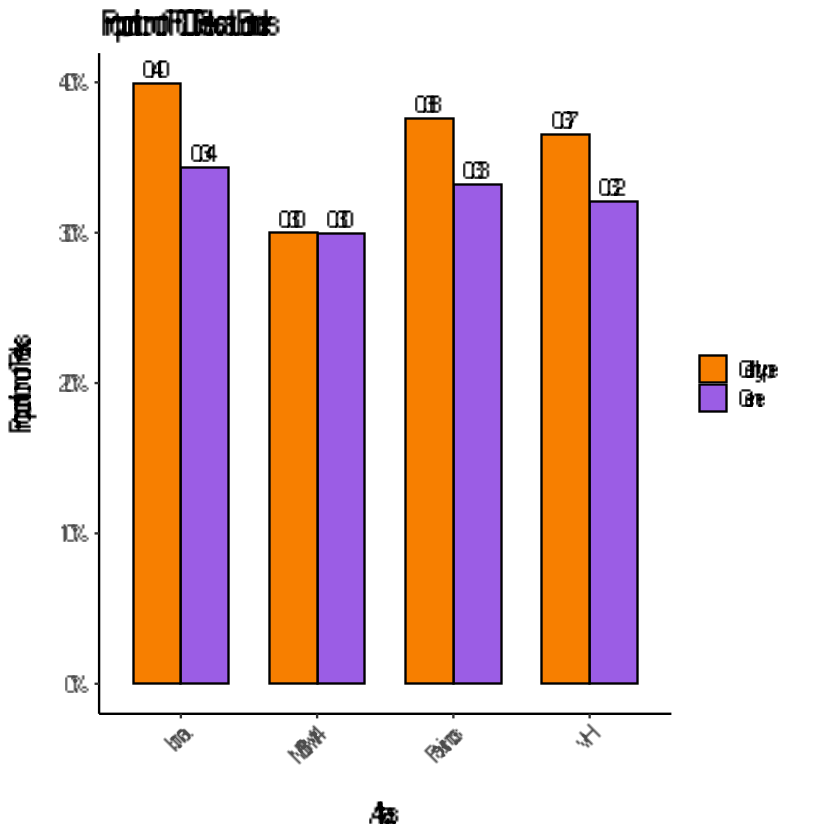

In [8]:
p1

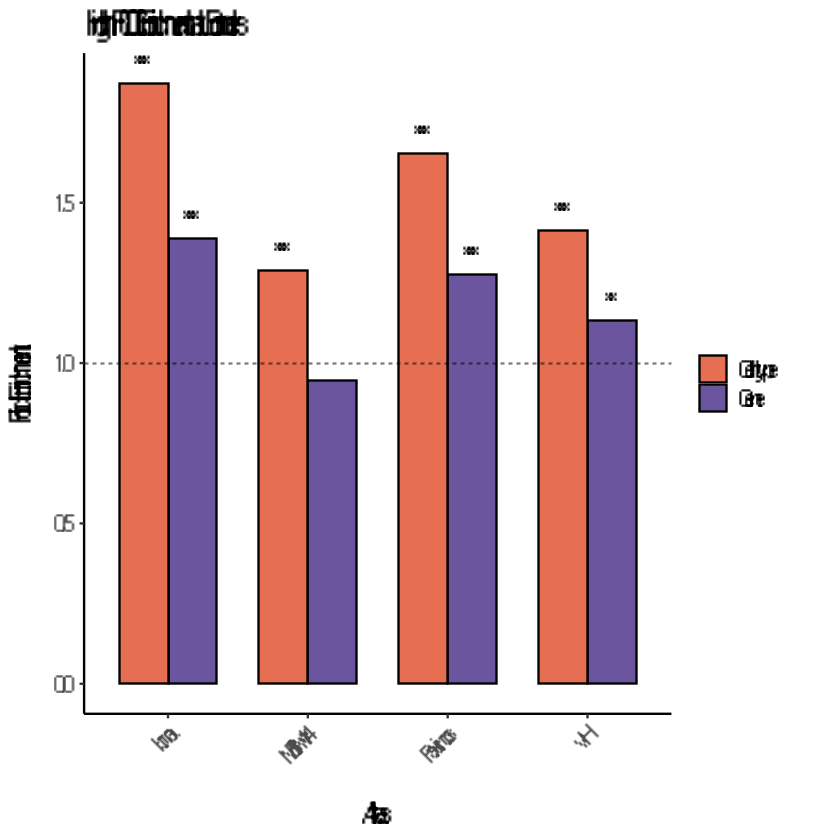

In [9]:
p2

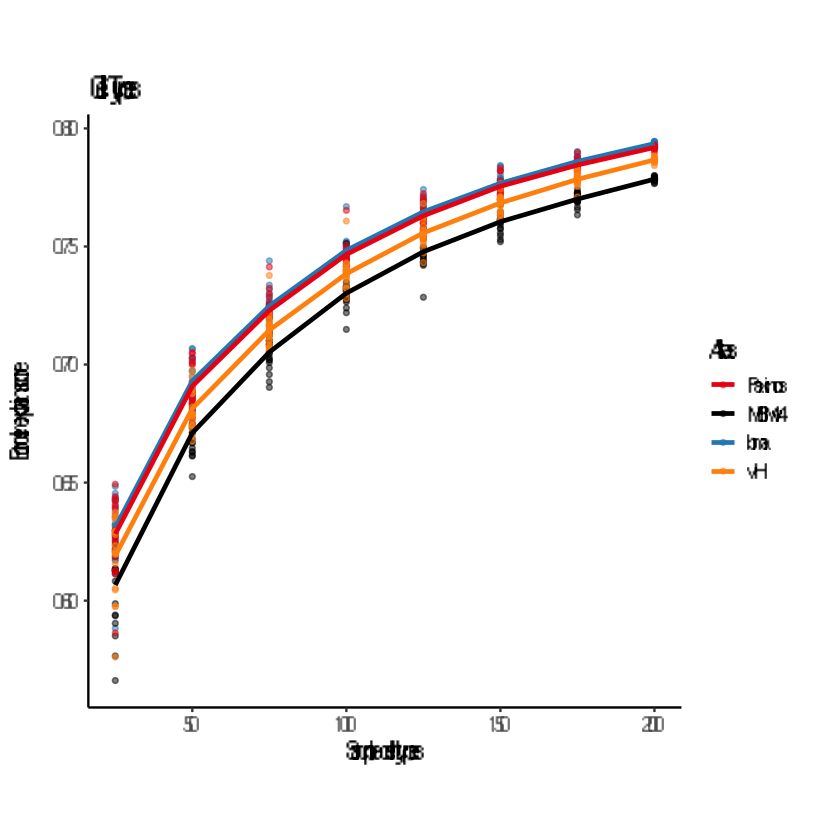

In [10]:
p3

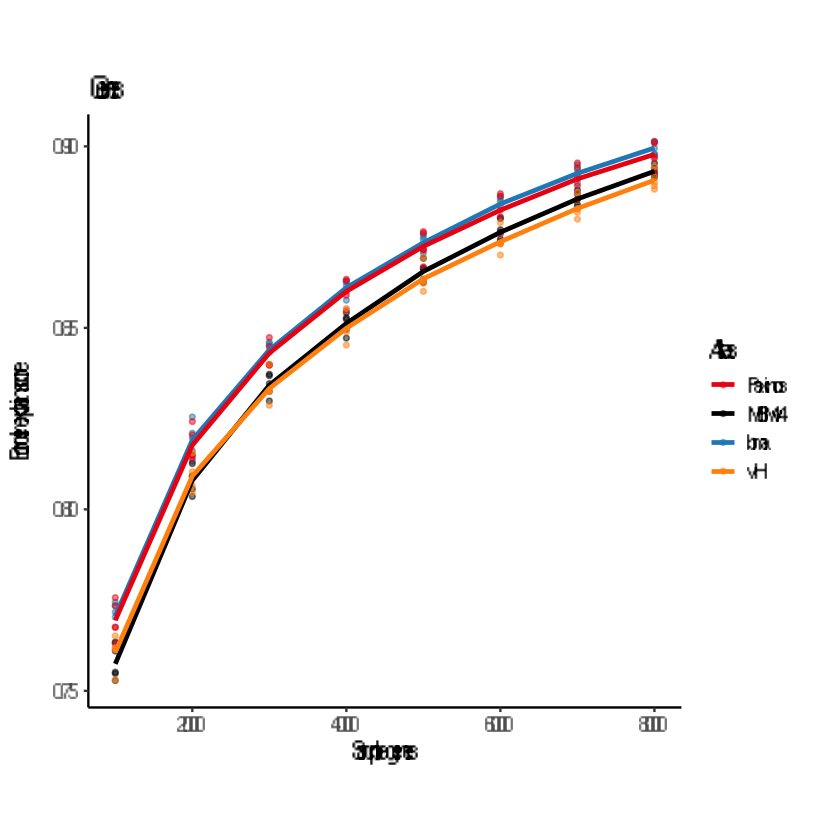

In [11]:
p4

In [12]:
# Save results
ggsave(file.path(output_dir, "peak_proportion.pdf"), p1, width = 8, height = 6)
ggsave(file.path(output_dir, "enrichment.pdf"), p2, width = 8, height = 6)
ggsave(file.path(output_dir, "explanation_celltype.pdf"), p3, width = 6, height = 5)
ggsave(file.path(output_dir, "explanation_gene.pdf"), p4, width = 6, height = 5)

write_csv(peak_proportions, file.path(output_dir, "peak_proportion_results.csv"))
write_csv(enrichment_data, file.path(output_dir, "enrichment_results.csv"))
write_csv(all_celltype_results, file.path(output_dir, "celltype_border_explanation.csv"))
write_csv(all_gene_results, file.path(output_dir, "gene_border_explanation.csv"))